# Frontera y sensibilidad del label L2 (EWE)

**Objetivo**: dejar que los datos hablen sobre qué tan robusto es el label L2
(Extreme Wildfire Event = FLI ≥ 10.000 kW/m, Tedim 2018) en el subset 2016-2017.

La corrida real dio **solo 5 EWE** de 12.381 eventos. Con N tan chico, un evento
de diferencia mueve la prevalencia ~20%. Aquí se examina:

1. Distribución de FLI y dónde cae el umbral.
2. Los 5 EWE y los eventos en la frontera (casi-EWE, bloqueados por la guardia de área).
3. Sensibilidad de N(EWE) a: umbral FLI, fracción radiante η_r y guardia de área.
4. Comparación L2 (FLI satelital) vs L1b (hectáreas P99/Pareto).
5. Lectura: ¿basta 2016-2017 o conviene ampliar años antes de modelar?

> Nota: las 36 columnas ERA5 están 100% nulas en este subset, por eso no hay cruces climáticos.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.modis import (FLI_EWE_THRESHOLD_KW_M, RADIANT_FRACTION,
                       MODIS_PIXEL_LENGTH_M, MIN_AREA_HA_FOR_L2, frp_to_fli)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")

AREA = "superficie_quemada_total_ha"
df = pd.read_parquet(ROOT / "data" / "processed" / "conaf_enriched_latest.parquet")
det = df[df["modis_frp_max_mw"].notna()].copy()   # solo eventos con detección MODIS

print(f"Umbral EWE        : {FLI_EWE_THRESHOLD_KW_M:,.0f} kW/m  (eta_r={RADIANT_FRACTION}, L_px={MODIS_PIXEL_LENGTH_M:.0f} m)")
print(f"Guardia de area   : {MIN_AREA_HA_FOR_L2:.0f} ha")
print(f"Eventos totales   : {len(df):,}")
print(f"Con deteccion MODIS: {len(det):,} ({100*len(det)/len(df):.1f}%)")
print(f"EWE (label_l2 = 1): {int(df['label_l2'].sum())}")

Umbral EWE        : 10,000 kW/m  (eta_r=0.17, L_px=1000 m)
Guardia de area   : 50 ha
Eventos totales   : 12,381
Con deteccion MODIS: 1,325 (10.7%)
EWE (label_l2 = 1): 5


## 1. Distribución de FLI

Solo los eventos con detección MODIS tienen FLI estimado. ¿Dónde cae la masa de la
distribución respecto al umbral EWE de 10.000 kW/m?

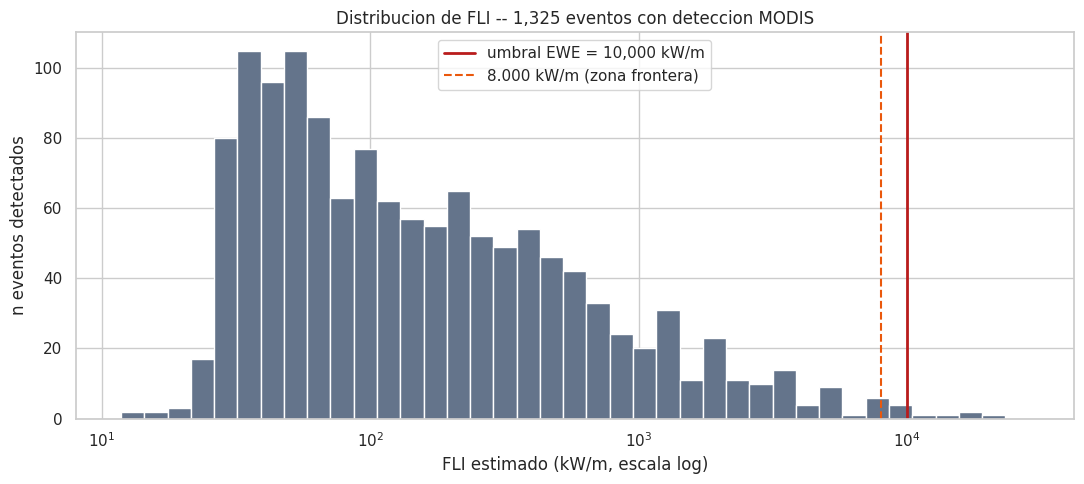

Conteo por banda de FLI:
       0 -    2,000 kW/m :  1256
   2,000 -    5,000 kW/m :    48
   5,000 -    8,000 kW/m :    11
   8,000 -   10,000 kW/m :     3
  10,000 -      inf kW/m :     7

Equivalencia: FLI 10,000 kW/m  <=>  FRP ~ 1,700 MW


In [2]:
fli = det["fli_estimado_kw_m"]
bins = np.logspace(np.log10(fli.min()), np.log10(fli.max()), 40)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(fli, bins=bins, color="#64748b", edgecolor="white")
ax.set_xscale("log")
ax.axvline(FLI_EWE_THRESHOLD_KW_M, color="#b91c1c", lw=2,
           label=f"umbral EWE = {FLI_EWE_THRESHOLD_KW_M:,.0f} kW/m")
ax.axvline(8000, color="#ea580c", lw=1.5, ls="--", label="8.000 kW/m (zona frontera)")
ax.set_xlabel("FLI estimado (kW/m, escala log)")
ax.set_ylabel("n eventos detectados")
ax.set_title(f"Distribucion de FLI -- {len(det):,} eventos con deteccion MODIS")
ax.legend()
plt.tight_layout(); plt.show()

print("Conteo por banda de FLI:")
for lo, hi in [(0,2000),(2000,5000),(5000,8000),(8000,10000),(10000,np.inf)]:
    n = int(((fli >= lo) & (fli < hi)).sum())
    hi_txt = "inf" if hi == np.inf else f"{hi:,.0f}"
    print(f"  {lo:>6,.0f} - {hi_txt:>8} kW/m : {n:>5}")

frp_umbral = FLI_EWE_THRESHOLD_KW_M * RADIANT_FRACTION * MODIS_PIXEL_LENGTH_M / 1000
print(f"\nEquivalencia: FLI {FLI_EWE_THRESHOLD_KW_M:,.0f} kW/m  <=>  FRP ~ {frp_umbral:,.0f} MW")

## 2. La frontera: los 5 EWE y sus vecinos

Tres grupos: (a) EWE confirmados, (b) casi-EWE justo por debajo del umbral con área
válida, (c) eventos que cruzan FLI pero los bloquea la guardia de área (falsos positivos
por atribución espacial del FRP de un megaincendio vecino).

In [3]:
area = det[AREA]
show = ["region", "comuna", "fecha_hora_inicio", AREA, "modis_frp_max_mw", "fli_estimado_kw_m"]

ewe  = det[(fli >= FLI_EWE_THRESHOLD_KW_M) & (area >= MIN_AREA_HA_FOR_L2)].sort_values("fli_estimado_kw_m", ascending=False)
casi = det[(fli >= 7000) & (fli < FLI_EWE_THRESHOLD_KW_M) & (area >= MIN_AREA_HA_FOR_L2)].sort_values("fli_estimado_kw_m", ascending=False)
bloq = det[(fli >= FLI_EWE_THRESHOLD_KW_M) & (area < MIN_AREA_HA_FOR_L2)].sort_values("fli_estimado_kw_m", ascending=False)

print(f"(a) EWE confirmados: {len(ewe)}")
display(ewe[show])
print(f"(b) casi-EWE (7.000-10.000 kW/m, area >= 50 ha): {len(casi)}  -- el mas cercano queda a {100*(1-casi['fli_estimado_kw_m'].max()/FLI_EWE_THRESHOLD_KW_M):.1f}% del umbral")
display(casi[show])
print(f"(c) bloqueados por la guardia de area (FLI >= 10.000, area < 50 ha): {len(bloq)}")
display(bloq[show])

(a) EWE confirmados: 5


,region,comuna,fecha_hora_inicio,superficie_quemada_total_ha,modis_frp_max_mw,fli_estimado_kw_m
9007,Biobío,Quirihue,2017-01-25 17:34:00,"10,829.8","4,819.3","28,348.8"
9574,Araucanía,Lumaco,2017-01-22 07:00:00,"1,848.7","3,798.6","22,344.7"
7235,Maule,Cauquenes,2017-01-20 22:01:00,"159,812.6","2,906.7","17,098.2"
6681,O'Higgins,Pumanque,2017-01-17 16:35:00,"46,490.0","1,825.0","10,735.3"
6594,O'Higgins,Paredones,2016-12-13 15:42:00,"1,298.0","1,746.9","10,275.9"


(b) casi-EWE (7.000-10.000 kW/m, area >= 50 ha): 5  -- el mas cercano queda a 4.0% del umbral


,region,comuna,fecha_hora_inicio,superficie_quemada_total_ha,modis_frp_max_mw,fli_estimado_kw_m
4332,Araucanía,Perquenco,2016-02-10 15:20:00,"1,100.0","1,631.8","9,598.8"
8962,Biobío,Penco,2017-01-25 15:07:00,340.7,"1,258.1","7,400.6"
8976,Biobío,Concepción,2017-01-25 18:14:00,"2,240.4","1,258.1","7,400.6"
6545,O'Higgins,Litueche,2016-11-17 12:53:00,"3,438.0","1,233.5","7,255.9"
9011,Biobío,Portezuelo,2017-01-28 10:00:00,"4,353.2","1,199.5","7,055.9"


(c) bloqueados por la guardia de area (FLI >= 10.000, area < 50 ha): 2


,region,comuna,fecha_hora_inicio,superficie_quemada_total_ha,modis_frp_max_mw,fli_estimado_kw_m
8994,Biobío,Tomé,2017-01-26 15:46:00,0.0,"2,940.8","17,298.8"
8379,Biobío,Hualqui,2017-01-26 09:44:00,0.2,"2,230.7","13,121.8"


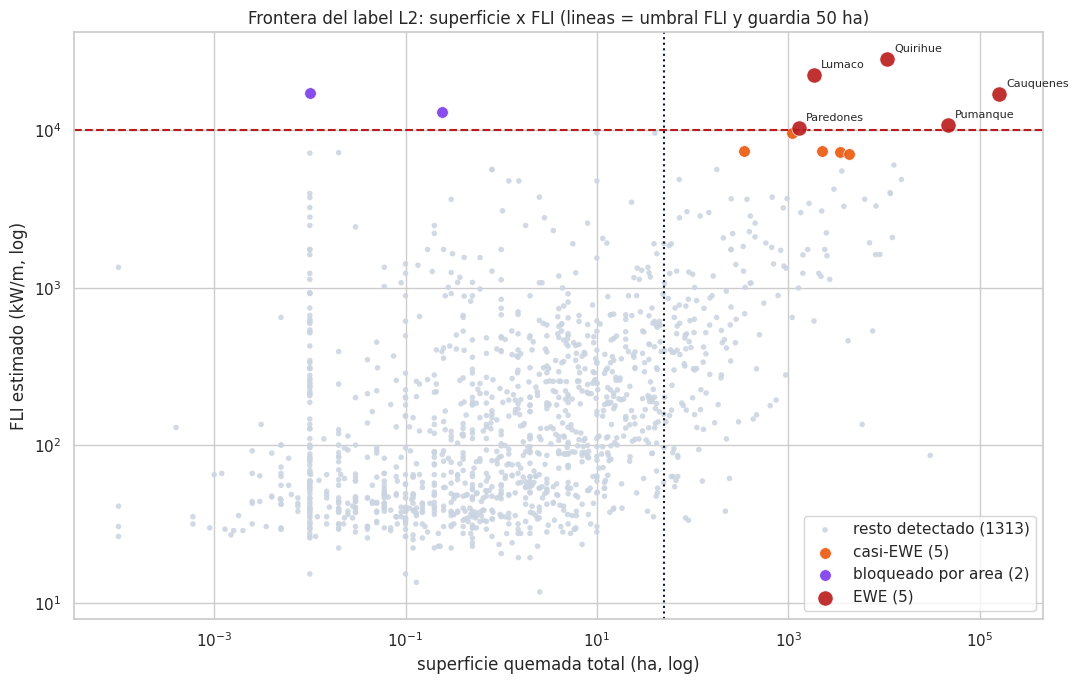

In [4]:
d = det[det[AREA] > 0].copy()
d["categoria"] = "resto detectado"
d.loc[(d["fli_estimado_kw_m"] >= 7000) & (d["fli_estimado_kw_m"] < FLI_EWE_THRESHOLD_KW_M) & (d[AREA] >= MIN_AREA_HA_FOR_L2), "categoria"] = "casi-EWE"
d.loc[(d["fli_estimado_kw_m"] >= FLI_EWE_THRESHOLD_KW_M) & (d[AREA] < MIN_AREA_HA_FOR_L2), "categoria"] = "bloqueado por area"
d.loc[(d["fli_estimado_kw_m"] >= FLI_EWE_THRESHOLD_KW_M) & (d[AREA] >= MIN_AREA_HA_FOR_L2), "categoria"] = "EWE"

palette = {"resto detectado": "#cbd5e1", "casi-EWE": "#ea580c", "bloqueado por area": "#7c3aed", "EWE": "#b91c1c"}
sizes   = {"resto detectado": 16, "casi-EWE": 70, "bloqueado por area": 70, "EWE": 120}

fig, ax = plt.subplots(figsize=(11, 7))
for cat, color in palette.items():
    sub = d[d["categoria"] == cat]
    ax.scatter(sub[AREA], sub["fli_estimado_kw_m"], s=sizes[cat], c=color,
               label=f"{cat} ({len(sub)})", alpha=0.9,
               edgecolor="none" if cat == "resto detectado" else "white",
               linewidth=0.5, zorder=3 if cat == "EWE" else 2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.axhline(FLI_EWE_THRESHOLD_KW_M, color="#b91c1c", ls="--", lw=1.5)
ax.axvline(MIN_AREA_HA_FOR_L2, color="#0f172a", ls=":", lw=1.5)
ax.set_xlabel("superficie quemada total (ha, log)")
ax.set_ylabel("FLI estimado (kW/m, log)")
ax.set_title("Frontera del label L2: superficie x FLI (lineas = umbral FLI y guardia 50 ha)")
for _, r in d[d["categoria"] == "EWE"].iterrows():
    ax.annotate(r["comuna"], (r[AREA], r["fli_estimado_kw_m"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 3. Sensibilidad al umbral FLI

¿Cuántos EWE habría si moviéramos el umbral? La curva muestra qué tan frágil es N(EWE)
alrededor de los 10.000 kW/m (con la guardia de área fija en 50 ha).

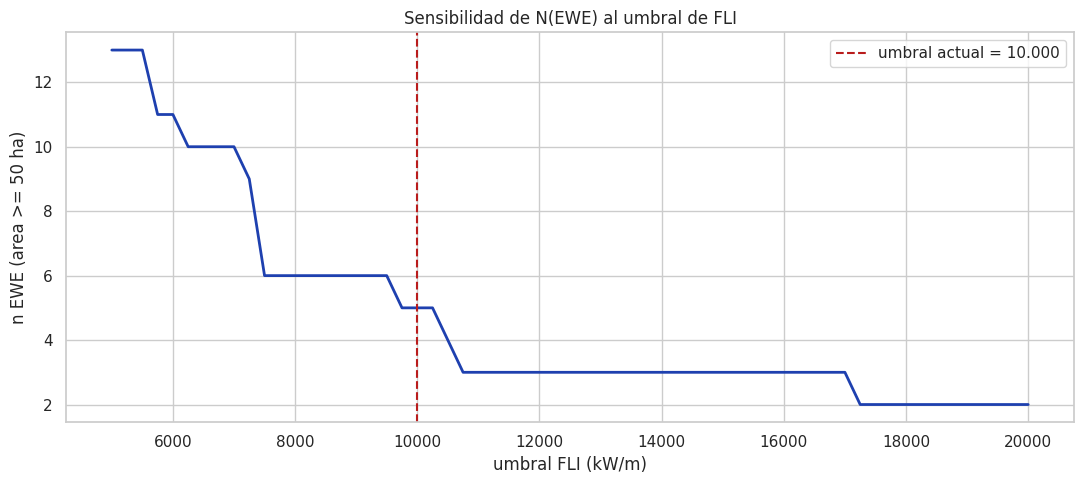

,umbral_kW_m,n_EWE
0,8000,6
1,9000,6
2,10000,5
3,11000,3
4,12000,3


In [5]:
area_ok = det[AREA] >= MIN_AREA_HA_FOR_L2
ths = np.arange(5000, 20001, 250)
n_curve = [int(((det["fli_estimado_kw_m"] >= t) & area_ok).sum()) for t in ths]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ths, n_curve, color="#1e40af", lw=2)
ax.axvline(FLI_EWE_THRESHOLD_KW_M, color="#b91c1c", ls="--", label="umbral actual = 10.000")
ax.set_xlabel("umbral FLI (kW/m)")
ax.set_ylabel("n EWE (area >= 50 ha)")
ax.set_title("Sensibilidad de N(EWE) al umbral de FLI")
ax.legend()
plt.tight_layout(); plt.show()

tabla = pd.DataFrame({"umbral_kW_m": [8000, 9000, 10000, 11000, 12000]})
tabla["n_EWE"] = [int(((det["fli_estimado_kw_m"] >= t) & area_ok).sum()) for t in tabla["umbral_kW_m"]]
display(tabla)

## 4. Sensibilidad a la fracción radiante η_r

Wooster 2003 reporta η_r en el rango 0,13–0,20; usamos 0,17 por defecto. Como
FLI ∝ 1/η_r, un η_r menor sube la FLI estimada y puede incorporar nuevos EWE.

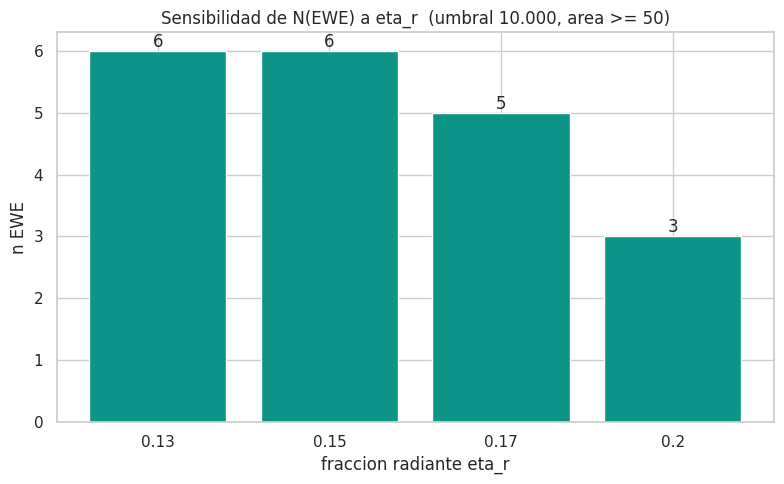

,eta_r,n_EWE
0,0.1,6
1,0.1,6
2,0.2,5
3,0.2,3


Eventos que entrarian a EWE si eta_r = 0.16: 1


,region,comuna,superficie_quemada_total_ha,modis_frp_max_mw,fli_estimado_kw_m
4332,Araucanía,Perquenco,"1,100.0","1,631.8","9,598.8"


In [6]:
frp = det["modis_frp_max_mw"]
etas = [0.13, 0.15, 0.17, 0.20]
sens_eta = pd.DataFrame({"eta_r": etas})
sens_eta["n_EWE"] = [
    int(((frp.apply(lambda f: frp_to_fli(f, MODIS_PIXEL_LENGTH_M, e)) >= FLI_EWE_THRESHOLD_KW_M) & area_ok).sum())
    for e in etas
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sens_eta["eta_r"].astype(str), sens_eta["n_EWE"], color="#0d9488")
ax.bar_label(bars)
ax.set_xlabel("fraccion radiante eta_r")
ax.set_ylabel("n EWE")
ax.set_title("Sensibilidad de N(EWE) a eta_r  (umbral 10.000, area >= 50)")
plt.tight_layout(); plt.show()
display(sens_eta)

fli_016 = frp.apply(lambda f: frp_to_fli(f, MODIS_PIXEL_LENGTH_M, 0.16))
nuevos = det[(fli_016 >= FLI_EWE_THRESHOLD_KW_M) & area_ok & (det["fli_estimado_kw_m"] < FLI_EWE_THRESHOLD_KW_M)]
print(f"Eventos que entrarian a EWE si eta_r = 0.16: {len(nuevos)}")
display(nuevos[["region", "comuna", AREA, "modis_frp_max_mw", "fli_estimado_kw_m"]])

## 5. Sensibilidad a la guardia de área

La guardia (área ≥ 50 ha) descarta falsos positivos donde el matching de 5 km captó el
FRP de un megaincendio vecino. ¿Cuánto cambia N(EWE) según dónde la pongamos?

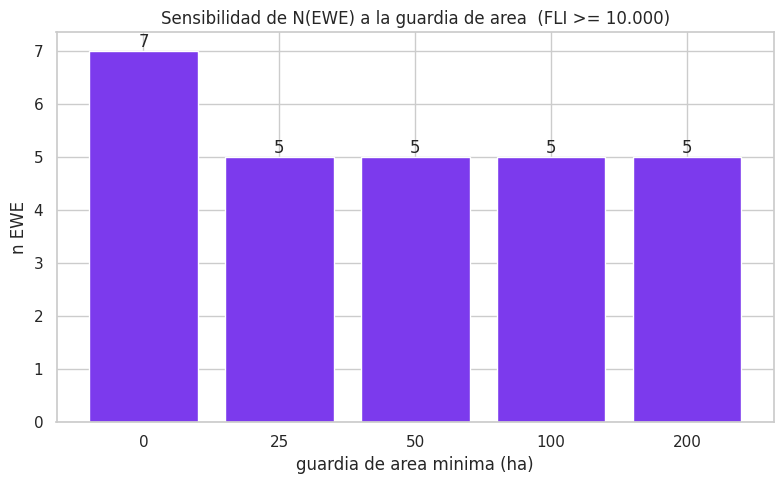

,A_min_ha,n_EWE
0,0,7
1,25,5
2,50,5
3,100,5
4,200,5


In [7]:
fli_ok = det["fli_estimado_kw_m"] >= FLI_EWE_THRESHOLD_KW_M
amins = [0, 25, 50, 100, 200]
sens_area = pd.DataFrame({"A_min_ha": amins})
sens_area["n_EWE"] = [int((fli_ok & (det[AREA] >= a)).sum()) for a in amins]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sens_area["A_min_ha"].astype(str), sens_area["n_EWE"], color="#7c3aed")
ax.bar_label(bars)
ax.set_xlabel("guardia de area minima (ha)")
ax.set_ylabel("n EWE")
ax.set_title("Sensibilidad de N(EWE) a la guardia de area  (FLI >= 10.000)")
plt.tight_layout(); plt.show()
display(sens_area)

## 6. Comparación L2 (FLI satelital) vs L1b (hectáreas)

L2 es el target objetivo (Tedim 2018); L1b es el proxy por superficie (umbral por región =
max(P99, Pareto-80) si n≥50, vía `scripts/megafire_thresholds.py`). Los desacuerdos son
lo interesante: un evento puede ser EWE por intensidad pero no por tamaño, y viceversa.

In [8]:
from scripts.megafire_thresholds import build_table

tabla_thr = build_table(df)
thr_map = tabla_thr[tabla_thr["region"] != "GLOBAL"].set_index("region")["recomendado_ha"].to_dict()
global_thr = float(tabla_thr.loc[tabla_thr["region"] == "GLOBAL", "recomendado_ha"].iloc[0])

df_cmp = df.copy()
df_cmp["umbral_l1b_region"] = df_cmp["region"].map(thr_map).fillna(global_thr)
df_cmp["label_l1b"] = (df_cmp[AREA] >= df_cmp["umbral_l1b_region"]).astype(int)

ct = pd.crosstab(df_cmp["label_l1b"], df_cmp["label_l2"], margins=True, margins_name="Total")
print("Tabla cruzada  L1b (filas) x L2 (columnas):")
display(ct)

solo_l2 = df_cmp[(df_cmp["label_l2"] == 1) & (df_cmp["label_l1b"] == 0)]
print(f"\nSolo-L2 (EWE por intensidad, NO megaincendio por hectareas): {len(solo_l2)}")
display(solo_l2[["region", "comuna", AREA, "umbral_l1b_region", "fli_estimado_kw_m"]])

solo_l1b = df_cmp[(df_cmp["label_l1b"] == 1) & (df_cmp["label_l2"] == 0)]
print(f"\nSolo-L1b (megaincendio por hectareas, NO EWE por intensidad): {len(solo_l1b)} -- top 10 por area")
display(solo_l1b.sort_values(AREA, ascending=False).head(10)[["region", "comuna", AREA, "modis_n_matches", "fli_estimado_kw_m"]])

Tabla cruzada  L1b (filas) x L2 (columnas):


label_l2,0,1,Total
label_l1b,,,
0,12298,1,12299
1,78,4,82
Total,12376,5,12381



Solo-L2 (EWE por intensidad, NO megaincendio por hectareas): 1


,region,comuna,superficie_quemada_total_ha,umbral_l1b_region,fli_estimado_kw_m
6594,O'Higgins,Paredones,"1,298.0","4,009.6","10,275.9"



Solo-L1b (megaincendio por hectareas, NO EWE por intensidad): 78 -- top 10 por area


,region,comuna,superficie_quemada_total_ha,modis_n_matches,fli_estimado_kw_m
7204,Maule,Vichuquén,"37,308.1",0,NaN
8923,Biobío,Florida,"30,391.1",3,86.5
8990,Biobío,Concepción,"15,204.7",20,"4,871.8"
6683,O'Higgins,Paredones,"12,684.0",24,"6,021.8"
8978,Biobío,San Nicolás,"12,249.4",25,"2,088.2"
8970,Biobío,Yumbel,"11,655.9",71,"3,968.2"
8965,Biobío,Hualqui,"9,051.4",22,"1,629.4"
6674,O'Higgins,Santa Cruz,"8,169.0",18,"1,625.3"
10501,Metropolitana,San Pedro,"7,980.5",0,NaN
10494,Metropolitana,Alhué,"7,606.5",4,532.9


## 7. Lectura: ¿basta 2016-2017 o conviene ampliar años?

La tabla siguiente resume N(EWE) bajo cada perturbación de parámetro.

In [9]:
def n_ewe(thr=FLI_EWE_THRESHOLD_KW_M, eta=RADIANT_FRACTION, amin=MIN_AREA_HA_FOR_L2):
    fli_e = det["modis_frp_max_mw"].apply(lambda f: frp_to_fli(f, MODIS_PIXEL_LENGTH_M, eta))
    return int(((fli_e >= thr) & (det[AREA] >= amin)).sum())

resumen = pd.DataFrame([
    ("actual: 10.000 / eta0.17 / 50 ha", n_ewe()),
    ("umbral FLI 8.000",  n_ewe(thr=8000)),
    ("umbral FLI 12.000", n_ewe(thr=12000)),
    ("eta_r = 0.13",      n_ewe(eta=0.13)),
    ("eta_r = 0.20",      n_ewe(eta=0.20)),
    ("sin guardia (A_min=0)", n_ewe(amin=0)),
    ("guardia 200 ha",    n_ewe(amin=200)),
], columns=["escenario", "n_EWE"])
display(resumen)
print(f"Rango de N(EWE) segun parametros: {resumen['n_EWE'].min()} - {resumen['n_EWE'].max()}")

,escenario,n_EWE
0,actual: 10.000 / eta0.17 / 50 ha,5
1,umbral FLI 8.000,6
2,umbral FLI 12.000,3
3,eta_r = 0.13,6
4,eta_r = 0.20,3
5,sin guardia (A_min=0),7
6,guardia 200 ha,5


Rango de N(EWE) segun parametros: 3 - 7


### Conclusión

- Con el N actual (**5 EWE**), el target es **estadísticamente frágil**: pequeñas variaciones
  en el umbral FLI, en η_r o en la guardia de área cambian la cuenta de positivos en ±2-3,
  es decir hasta ~50% de prevalencia relativa.
- Hay eventos **justo en la frontera** (Perquenco a −4% del umbral) que entrarían/saldrían
  con cambios menores y defendibles de parámetros.
- Para un clasificador supervisado, 5 positivos es insuficiente para train/test estable
  (incluso con `scale_pos_weight` y validación estratificada).

**Recomendación**: antes de modelar L2, **ampliar la ventana temporal** (más temporadas)
para acumular más EWE y dar robustez al target. Mientras tanto, fijar (η_r, umbral, guardia)
con justificación explícita y reportar este análisis de sensibilidad en el paper.